# MLP Extrapolation Failure: Consolidation Settlement

**Train on [0-2 years]** → **Predict [0-10 years]**

Data model: $S(t) = S_{\text{final}}(1 - e^{-\alpha t})$, an exponential model of
settlement with $\alpha$ a rate constant in 1/year. It is not Terzaghi's
one-dimensional consolidation solution, which is a Fourier series. See
`03c-mlp-function-approximation.ipynb` for the difference.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim

torch.manual_seed(42)
np.random.seed(42)

plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 11


## Generate Data

Training: 20 points, t ∈ [0, 2] years
Testing: 200 points, t ∈ [0, 10] years
Noise on the training targets: sigma = 2.0 mm


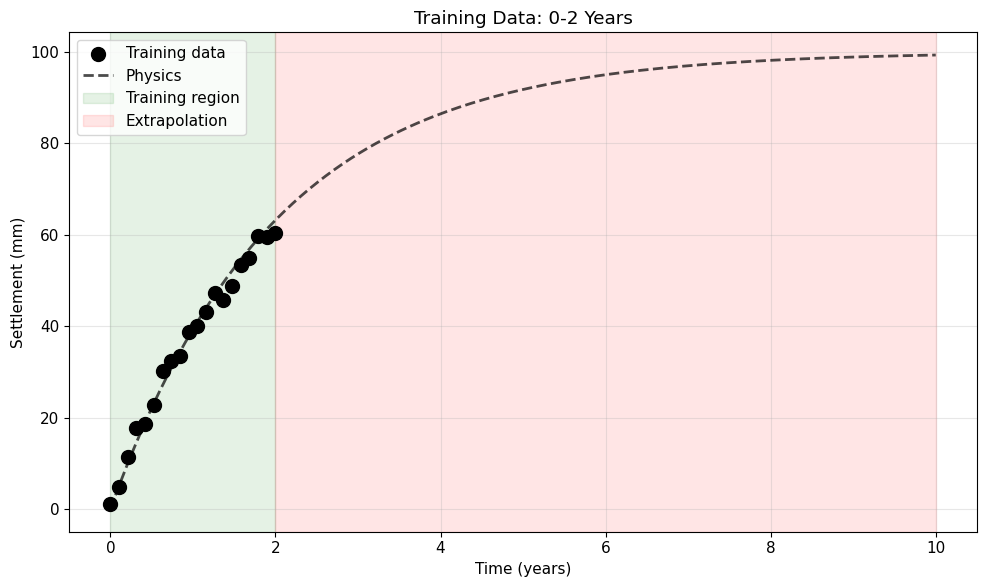

In [2]:
# Physics parameters
S_final = 100.0  # mm
alpha = 0.5      # 1/year

def settlement(t, S_final=100.0, alpha=0.5):
    return S_final * (1.0 - np.exp(-alpha * t))

# Training data: 0-2 years
t_train = np.linspace(0, 2, 20)
noise_sigma = 2.0  # mm
S_train = settlement(t_train) + np.random.normal(0, noise_sigma, len(t_train))
S_train = np.maximum(S_train, 0)

# Full range: 0-10 years
t_full = np.linspace(0, 10, 200)
S_physics = settlement(t_full)

# Convert to tensors
t_train_t = torch.FloatTensor(t_train.reshape(-1, 1))
S_train_t = torch.FloatTensor(S_train.reshape(-1, 1))
t_full_t = torch.FloatTensor(t_full.reshape(-1, 1))

print(f"Training: {len(t_train)} points, t ∈ [0, {t_train.max():.0f}] years")
print(f"Testing: {len(t_full)} points, t ∈ [0, {t_full.max():.0f}] years")
print(f"Noise on the training targets: sigma = {noise_sigma} mm")

# Plot training data
plt.figure(figsize=(10, 6))
plt.scatter(t_train, S_train, s=100, color='black', zorder=5, label='Training data')
plt.plot(t_full, S_physics, 'k--', linewidth=2, label='Physics', alpha=0.7)
plt.axvspan(0, 2, alpha=0.1, color='green', label='Training region')
plt.axvspan(2, 10, alpha=0.1, color='red', label='Extrapolation')
plt.xlabel('Time (years)')
plt.ylabel('Settlement (mm)')
plt.title('Training Data: 0-2 Years')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## MLP Architecture

In [3]:
class MLP(nn.Module):
    def __init__(self, activation='relu'):
        super().__init__()
        self.fc1 = nn.Linear(1, 32)
        self.fc2 = nn.Linear(32, 32)
        self.fc3 = nn.Linear(32, 1)

        # He initialization for ReLU, Xavier for the saturating activations. This is
        # the standard pairing. fc3 and every bias keep the PyTorch default. The fan-in
        # of fc1 is 1, so He gives std sqrt(2) here, a wide draw for a scalar input.
        # This notebook does not compare against the default, so it does not show that
        # the choice matters.
        if activation == 'relu':
            nn.init.kaiming_normal_(self.fc1.weight, mode='fan_in', nonlinearity='relu')
            nn.init.kaiming_normal_(self.fc2.weight, mode='fan_in', nonlinearity='relu')
        else:
            nn.init.xavier_normal_(self.fc1.weight)
            nn.init.xavier_normal_(self.fc2.weight)

        activations = {
            'relu': nn.ReLU(),
            'tanh': nn.Tanh(),
            'sigmoid': nn.Sigmoid(),
        }
        self.act = activations[activation]
        self.name = activation

    def forward(self, t):
        x = self.act(self.fc1(t))
        x = self.act(self.fc2(x))
        return self.fc3(x)

def train_model(activation, epochs=3000, seed=42):
    torch.manual_seed(seed)
    model = MLP(activation)
    optimizer = optim.Adam(model.parameters(), lr=0.01)
    criterion = nn.MSELoss()

    for epoch in range(epochs):
        optimizer.zero_grad()
        loss = criterion(model(t_train_t), S_train_t)
        loss.backward()
        optimizer.step()

    model.eval()
    with torch.no_grad():
        pred = model(t_full_t).numpy().flatten()

    return model, pred

## Train All Models

In [4]:
activations = ['relu', 'tanh', 'sigmoid']
models = {}
predictions = {}

for act in activations:
    print(f"Training {act.upper()}...", end=' ')
    model, pred = train_model(act, epochs=3000)
    models[act] = model
    predictions[act] = pred
    print("Done")

print(f"\nAll {len(activations)} models trained")

Training RELU... 

Done
Training TANH... 

Done
Training SIGMOID... 

Done

All 3 models trained


## Results: Training vs Extrapolation

In [5]:
# Compute errors
train_mask = t_full <= 2.0
extrap_mask = t_full > 2.0

print(f"{'Activation':<10} {'Train RMSE':<12} {'Extrap RMSE':<12} {'Max S':<10} {'Exceeds?'}")
print("-" * 60)

for act in activations:
    pred = predictions[act]
    rmse_train = np.sqrt(np.mean((pred[train_mask] - S_physics[train_mask])**2))
    rmse_extrap = np.sqrt(np.mean((pred[extrap_mask] - S_physics[extrap_mask])**2))
    max_s = pred.max()
    exceeds = "YES" if max_s > S_final + 5 else "NO"

    print(f"{act.upper():<10} {rmse_train:>10.2f} mm {rmse_extrap:>10.2f} mm {max_s:>8.1f} mm {exceeds:>7}")

print(f"{'PHYSICS':<10} {'0.00 mm':>12} {'0.00 mm':>12} {S_physics[-1]:>8.1f} mm {'NO':>7}")

Activation Train RMSE   Extrap RMSE  Max S      Exceeds?
------------------------------------------------------------
RELU             1.51 mm      87.62 mm    264.1 mm     YES
TANH             1.69 mm      30.60 mm     61.9 mm      NO
SIGMOID          1.59 mm      30.94 mm     61.5 mm      NO
PHYSICS         0.00 mm      0.00 mm     99.3 mm      NO


## Interpolation: Training Region [0-2 years]

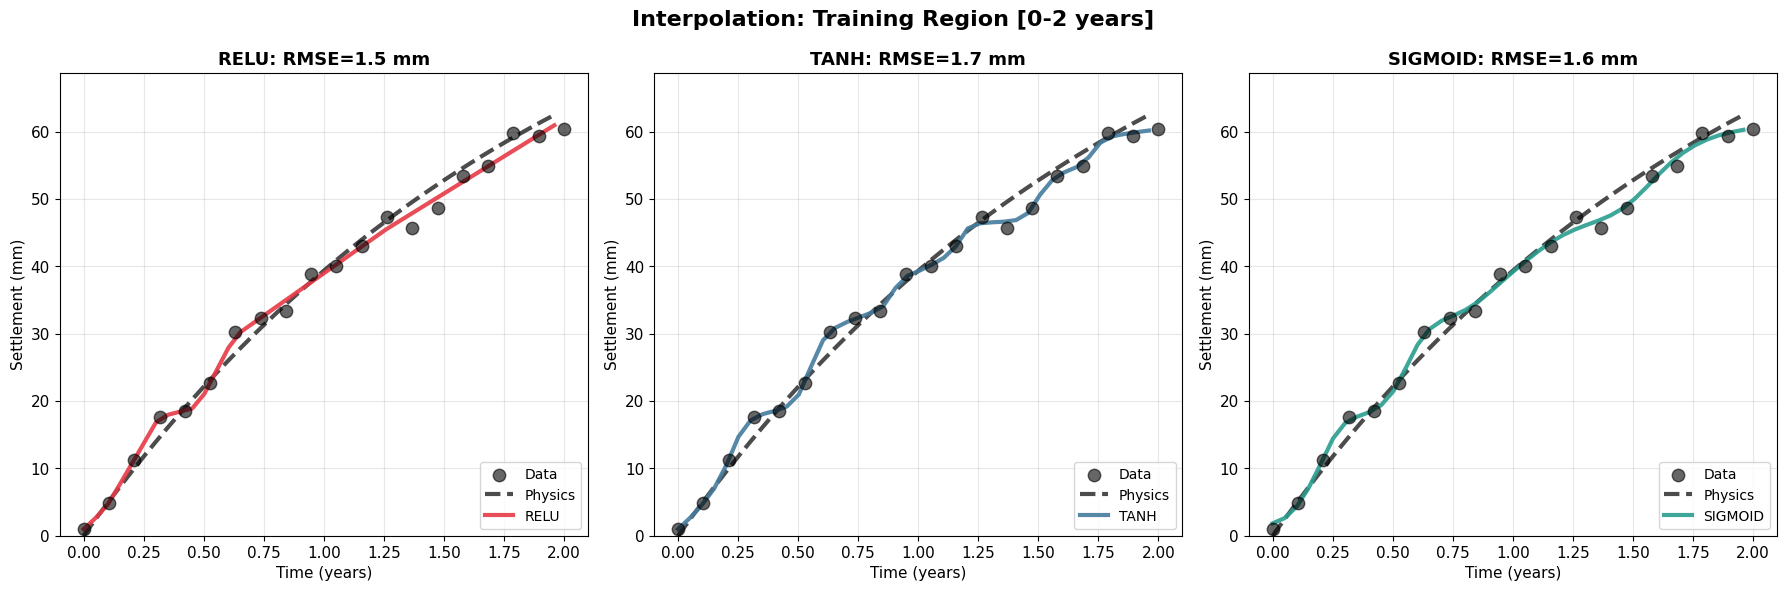

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

colors = {
    'relu': '#E63946',
    'tanh': '#457B9D',
    'sigmoid': '#2A9D8F'
}

for idx, act in enumerate(activations):
    ax = axes[idx]

    # Only plot training region
    t_train_region = t_full[train_mask]
    S_train_region = S_physics[train_mask]
    pred_train_region = predictions[act][train_mask]

    ax.scatter(t_train, S_train, s=80, color='black', zorder=5, alpha=0.6, label='Data')
    ax.plot(t_train_region, S_train_region, 'k--', linewidth=3, label='Physics', alpha=0.7)
    ax.plot(t_train_region, pred_train_region, color=colors[act], linewidth=3,
            label=f'{act.upper()}', alpha=0.9)

    rmse_train = np.sqrt(np.mean((pred_train_region - S_train_region)**2))

    ax.set_title(f'{act.upper()}: RMSE={rmse_train:.1f} mm',
                 fontsize=13, fontweight='bold')
    ax.set_xlabel('Time (years)', fontsize=11)
    ax.set_ylabel('Settlement (mm)', fontsize=11)
    ax.legend(loc='lower right', fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(-0.1, 2.1)
    ax.set_ylim(0, S_train_region.max()*1.1)

plt.suptitle('Interpolation: Training Region [0-2 years]',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## Extrapolation: Full Range [0-10 years]

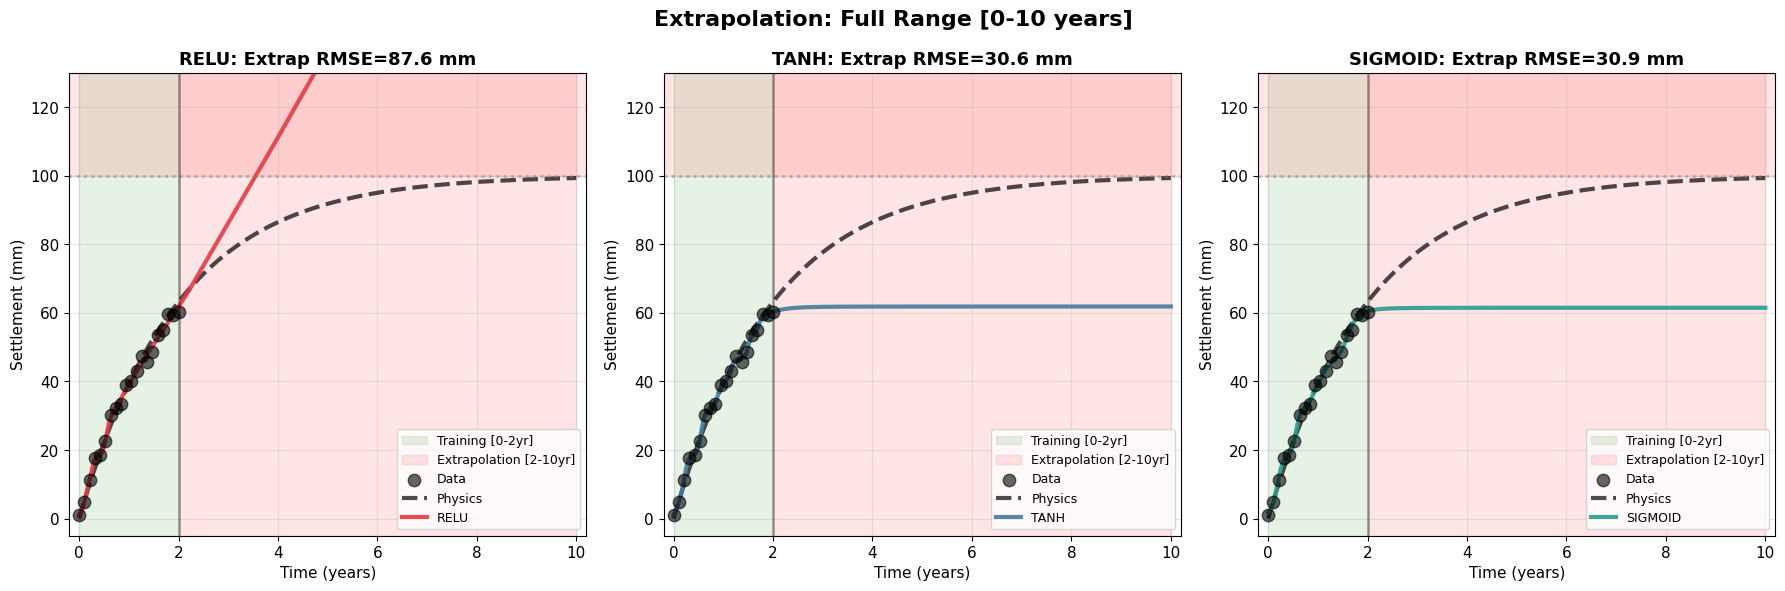


20-Year Predictions:
Activation S(20yr)      Error
-----------------------------------
RELU            518.9 mm    418.9 mm
TANH             61.9 mm     38.1 mm
SIGMOID          61.5 mm     38.5 mm
PHYSICS         100.0 mm   0.0 mm


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for idx, act in enumerate(activations):
    ax = axes[idx]

    # Full range [0-10 years]
    ax.axvspan(0, 2, alpha=0.1, color='green', label='Training [0-2yr]')
    ax.axvspan(2, 10, alpha=0.1, color='red', label='Extrapolation [2-10yr]')
    ax.axhspan(S_final, S_final*1.3, alpha=0.1, color='red')

    ax.scatter(t_train, S_train, s=80, color='black', zorder=5, alpha=0.6, label='Data')
    ax.plot(t_full, S_physics, 'k--', linewidth=3, label='Physics', alpha=0.7)
    ax.plot(t_full, predictions[act], color=colors[act], linewidth=3,
            label=f'{act.upper()}', alpha=0.9)

    ax.axhline(S_final, color='gray', linestyle=':', linewidth=2, alpha=0.5)
    ax.axvline(2.0, color='black', linestyle='-', linewidth=2, alpha=0.3)

    pred = predictions[act]
    rmse_extrap = np.sqrt(np.mean((pred[extrap_mask] - S_physics[extrap_mask])**2))

    ax.set_title(f'{act.upper()}: Extrap RMSE={rmse_extrap:.1f} mm',
                 fontsize=13, fontweight='bold')
    ax.set_xlabel('Time (years)', fontsize=11)
    ax.set_ylabel('Settlement (mm)', fontsize=11)
    ax.legend(loc='lower right', fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_xlim(-0.2, 10.2)
    ax.set_ylim(-5, S_final*1.3)

plt.suptitle('Extrapolation: Full Range [0-10 years]',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n20-Year Predictions:")
print(f"{'Activation':<10} {'S(20yr)':<12} {'Error'}")
print("-" * 35)

t_ext = np.linspace(0, 20, 400)
S_ext_physics = settlement(t_ext)
t_ext_t = torch.FloatTensor(t_ext.reshape(-1, 1))

for act in activations:
    with torch.no_grad():
        pred_20 = models[act](torch.FloatTensor([[20.0]])).item()
    error = abs(pred_20 - S_ext_physics[-1])
    print(f"{act.upper():<10} {pred_20:>10.1f} mm {error:>8.1f} mm")
print(f"{'PHYSICS':<10} {S_ext_physics[-1]:>10.1f} mm {'0.0 mm':>8}")

## Summary

**Key Findings:**

1. All three models reach the noise level on the training interval. The added noise has
   $\sigma = 2$ mm, and the train RMSE above is measured against the noiseless curve
   `S_physics`, not against the noisy targets. An RMSE near 2 mm is the noise level and
   cannot go much lower.
2. All three fail outside the training interval.
3. ReLU is the worst. A ReLU network is piecewise linear with finitely many breakpoints,
   so beyond the largest breakpoint its output is exactly affine in $t$ and grows without
   limit. No seed changes this.
4. Tanh and sigmoid saturate, so the prediction tends to a constant. The constant they
   reach is not $S_{\text{final}}$. Training stops at $t = 2$ years where the true
   settlement is only 63.2 mm, so the asymptote is not in the data.

**Scope of these numbers.** One initialization per activation. The exact plateau values
and the exact 20-year numbers depend on the seed for tanh and sigmoid. Only the affine
ReLU tail is guaranteed by the model class. The shapes generalise, the digits do not.

This notebook runs no non-MLP baseline, so it does not separate how much of the error
comes from the hypothesis class and how much from having only two years of data.

**Lesson:** Training accuracy is not extrapolation reliability.
